# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [ ]:
# !pip install sklearn.LabelEncoder

In [1]:
# Install scikit-learn if missing
%pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load data
df = pd.read_csv('data.csv')

In [3]:
# First 5 Rows of the dataset
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# 1st row of the dataset
print("First row of the dataset:")
df.iloc[0,:]

First row of the dataset:


age                        56
job                 housemaid
marital               married
education            basic.4y
default                    no
housing                    no
loan                       no
contact             telephone
month                     may
day_of_week               mon
duration                  261
campaign                    1
pdays                     999
previous                    0
poutcome          nonexistent
emp.var.rate              1.1
cons.price.idx         93.994
cons.conf.idx           -36.4
euribor3m               4.857
nr.employed            5191.0
y                          no
Name: 0, dtype: object

In [5]:
# Dataset info
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188

In [6]:
# Dataset Description
print("Dataset Description:")
print(df.describe())

Dataset Description:
               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1.570960        0.5788

In [7]:
# Null values in the dataset
print("Null values in the dataset:")
print(df.isnull().sum())

Null values in the dataset:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


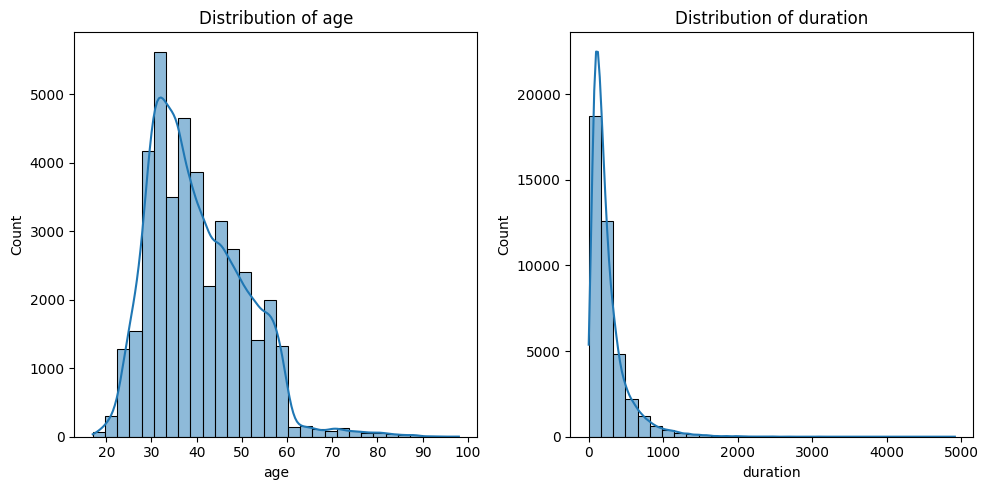

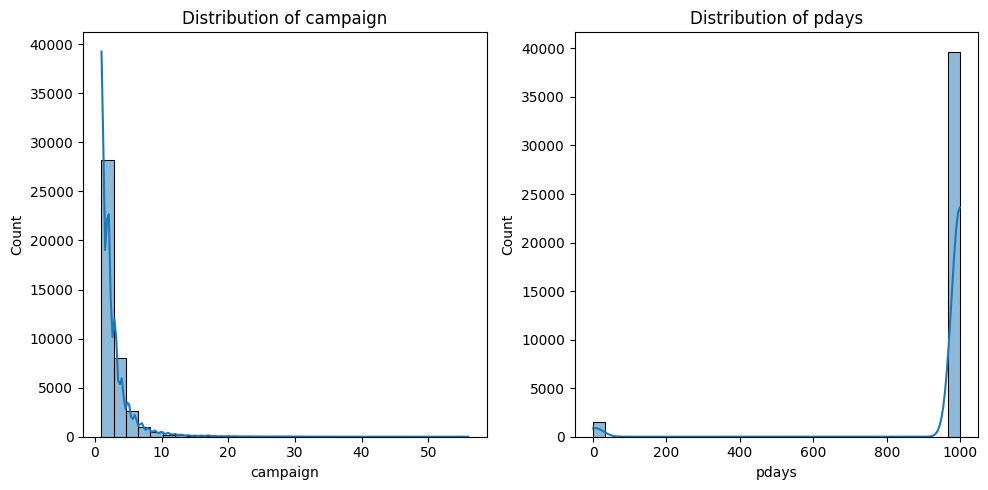

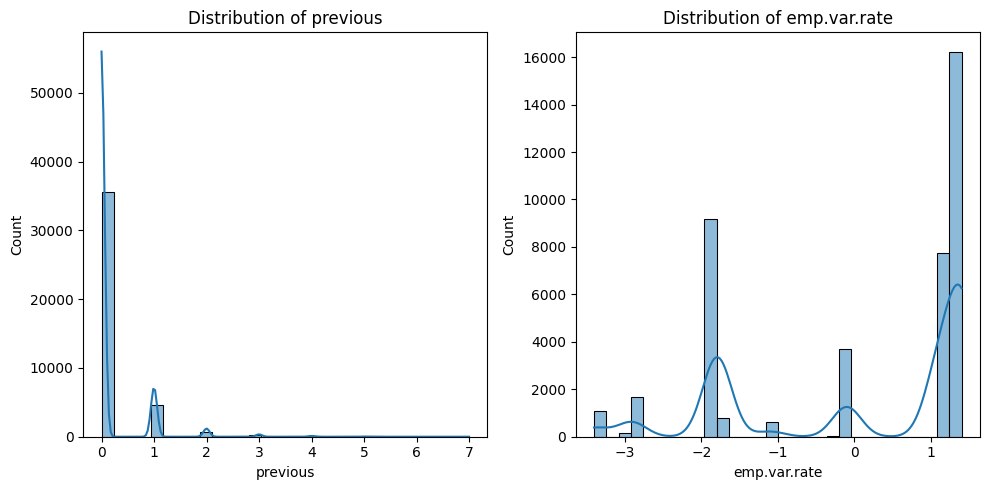

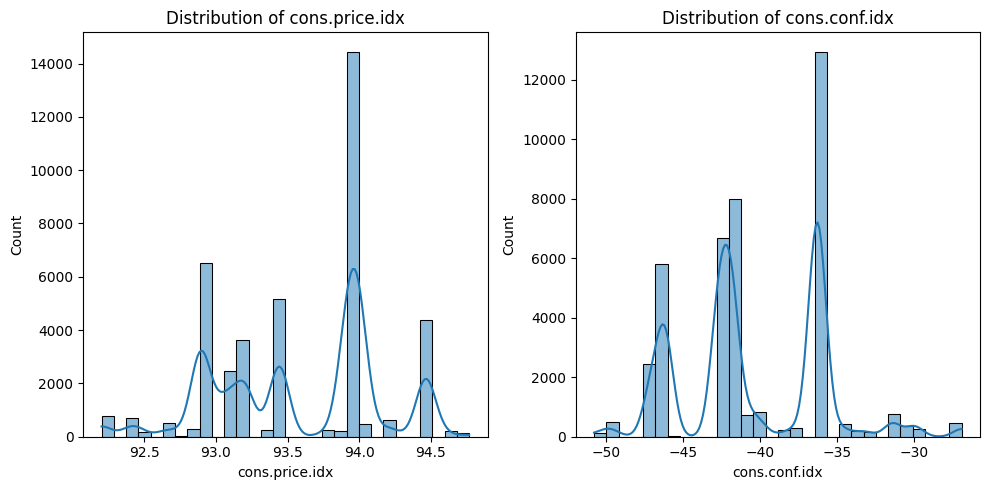

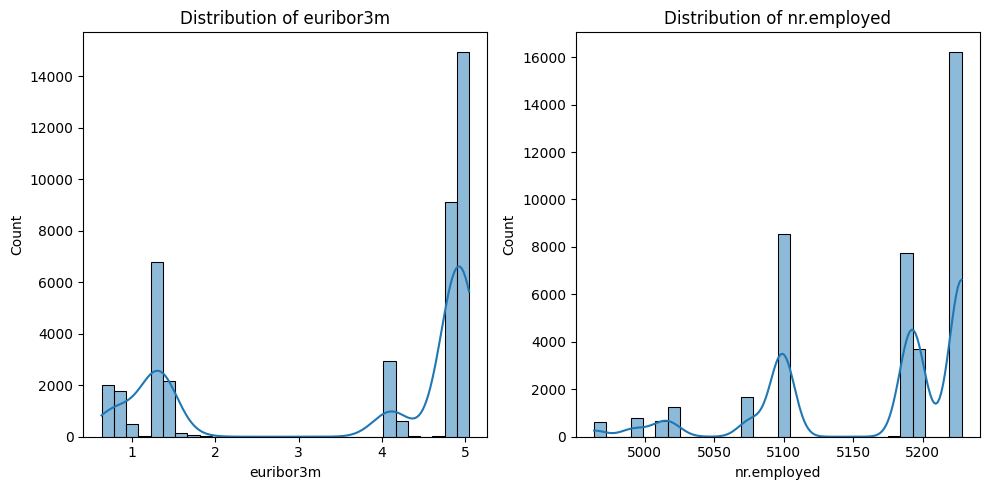

In [8]:
# Numerical columns distribution
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for i in range(0, len(numerical_columns), 2):
    plt.figure(figsize=(10,5))
    for j in range(2):
        if i + j < len(numerical_columns):
            plt.subplot(1, 2, j + 1)
            sns.histplot(df[numerical_columns[i + j]], kde=True, bins=30)
            plt.title(f'Distribution of {numerical_columns[i + j]}')
    plt.tight_layout()
    plt.show()

<Figure size 1000x600 with 0 Axes>

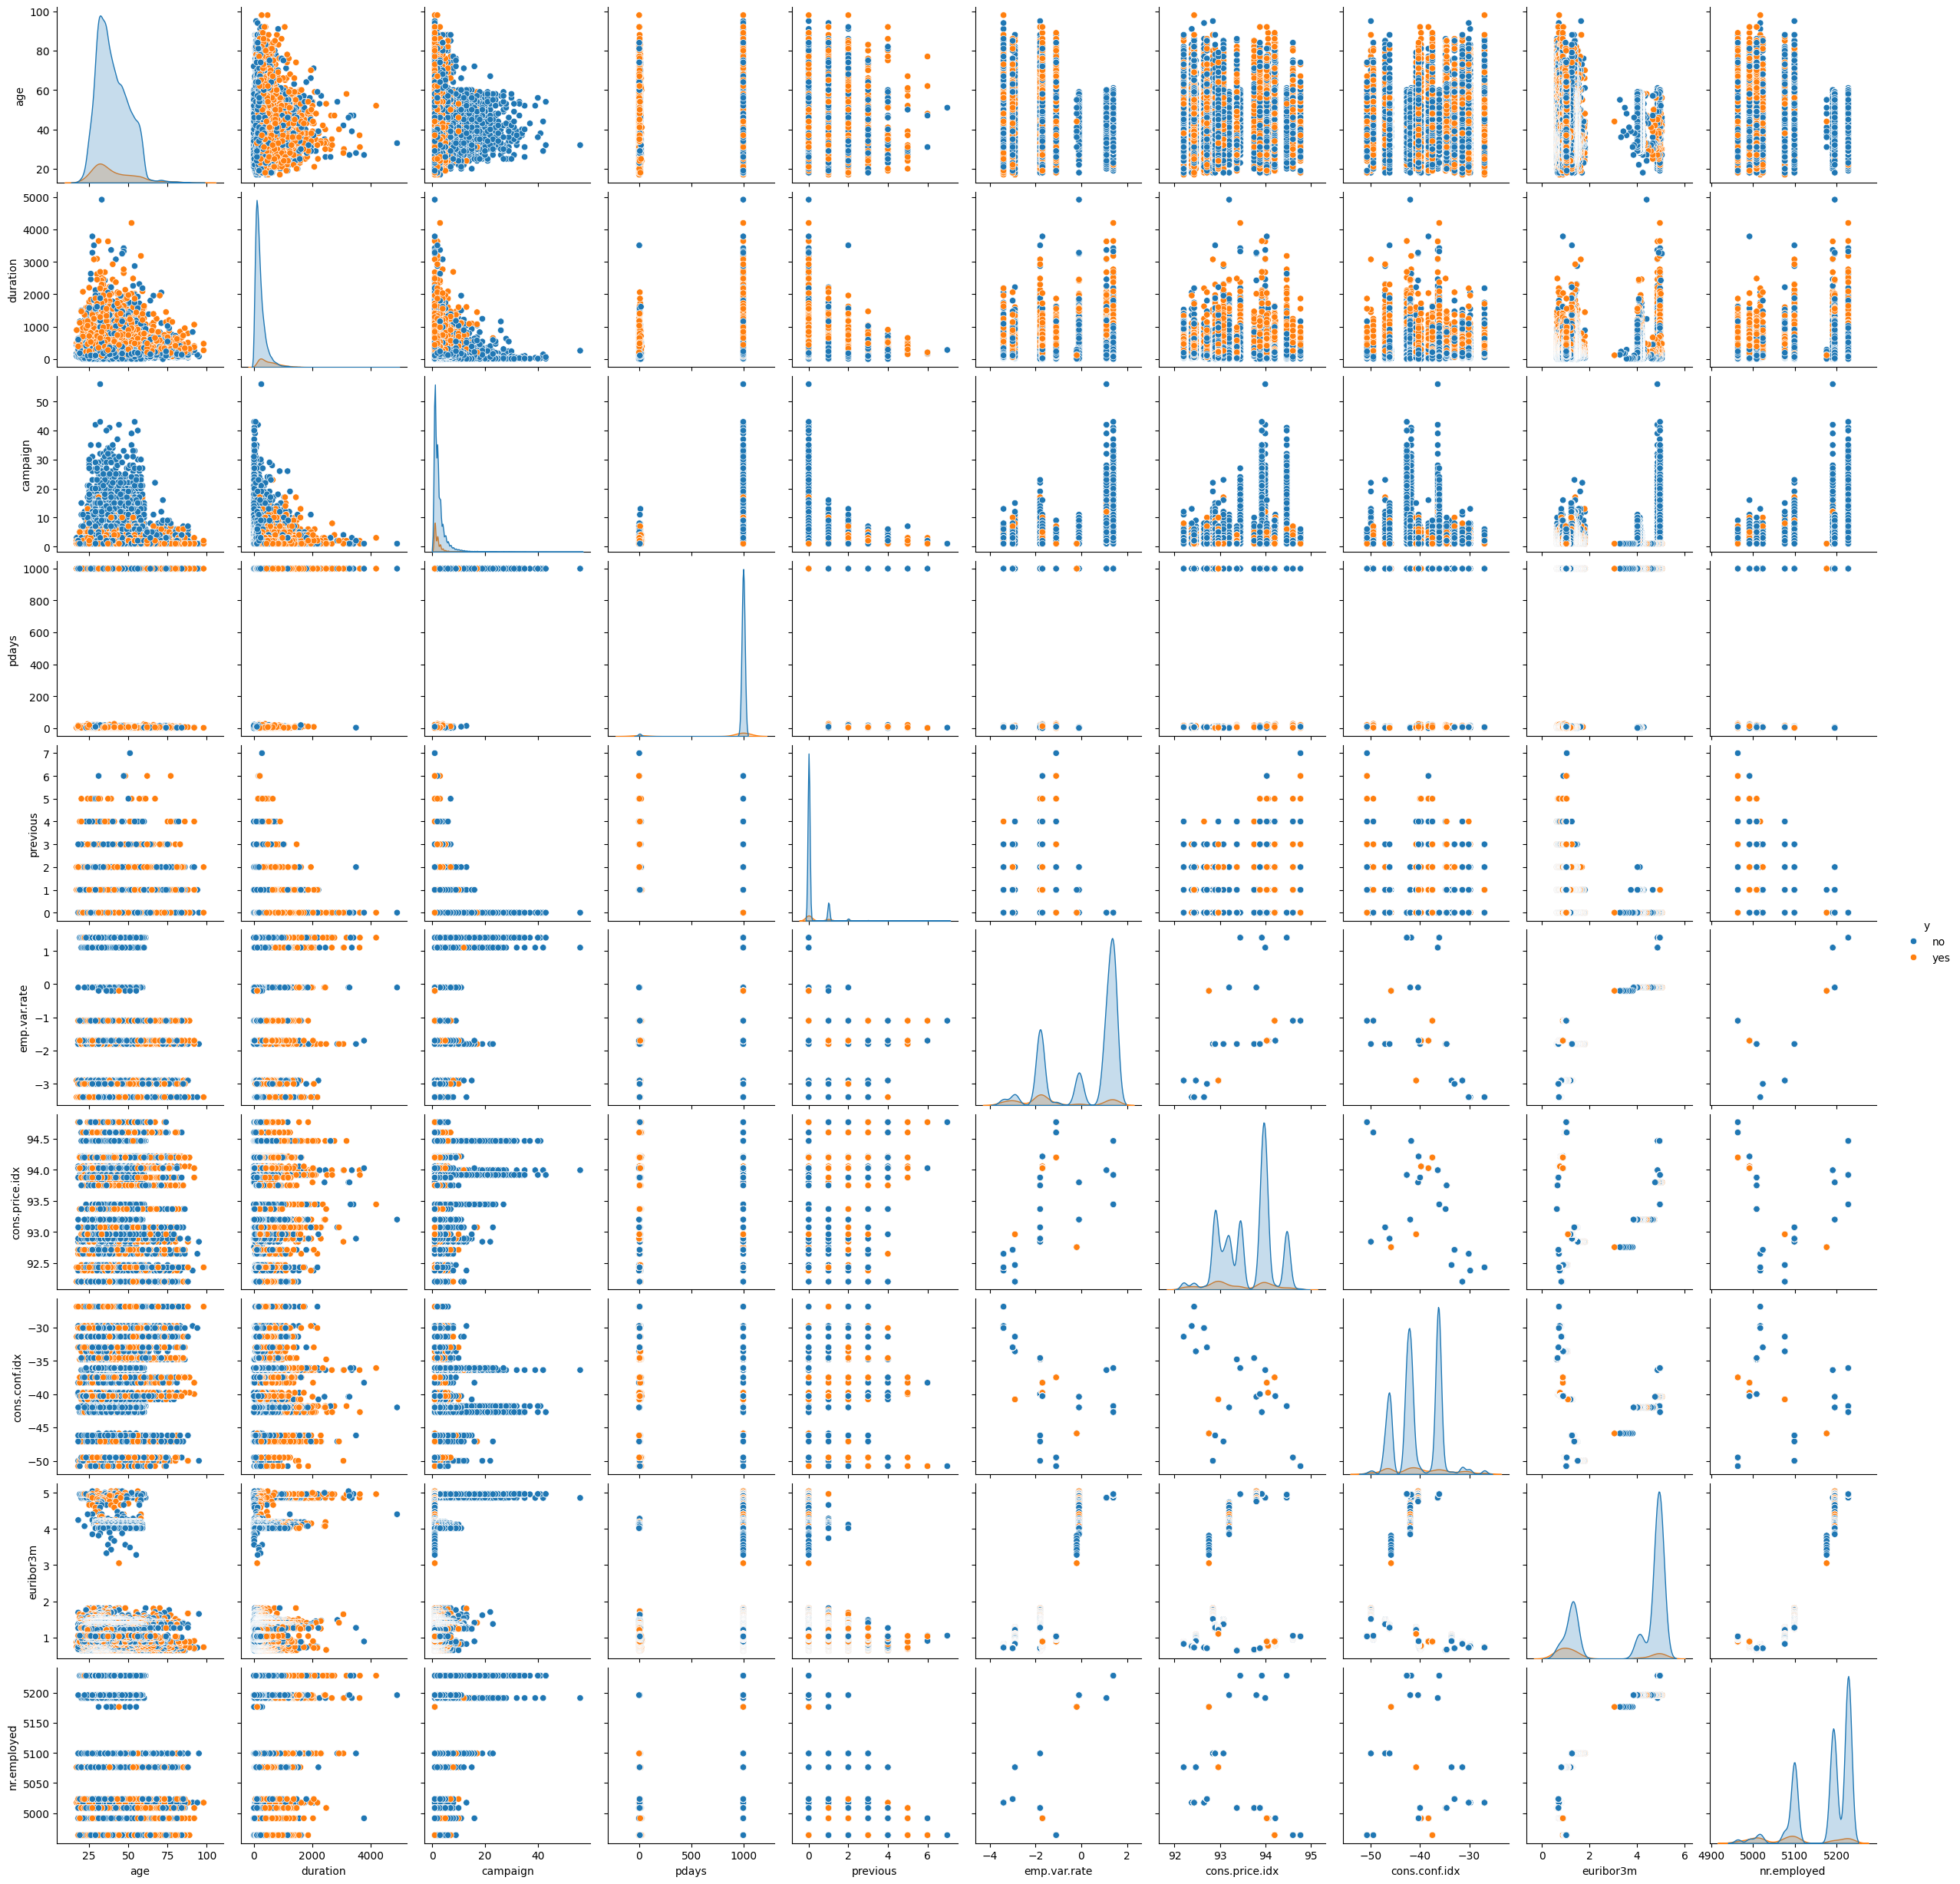

In [9]:
# Multivariate analysis
plt.figure(figsize=(10, 6))
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num['y'] = df['y']
sns.pairplot(df_num, hue = 'y')
plt.show()

## Customer Demographics Analysis

In [10]:
# Age distribution
age_dict = dict()
for i in range(0,100,10):
    age_dict[f'{i}-{i+10}'] = df[(df['age'] >= i) & (df['age'] <= i+10)].shape[0]

age_df = pd.DataFrame(list(age_dict.items()), columns=["Age Range", "Number of People"])
print(age_df)

  Age Range  Number of People
0      0-10                 0
1     10-20               140
2     20-30              7308
3     30-40             18099
4     40-50             11401
5     50-60              7145
6     60-70               771
7     70-80               350
8     80-90               140
9    90-100                10


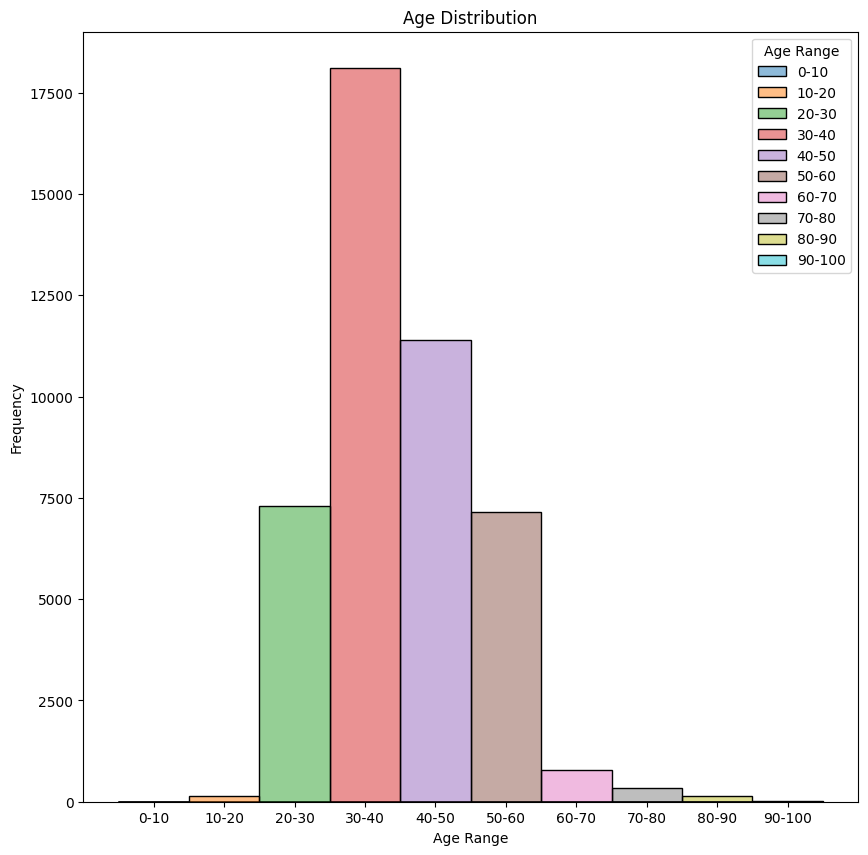

In [11]:
# Age distribution
plt.figure(figsize=(10, 10))
sns.histplot(data=age_df, x="Age Range", weights="Number of People", hue="Age Range", kde=True)
plt.title('Age Distribution')
plt.xlabel('Age Range')
plt.ylabel('Frequency')
plt.show()

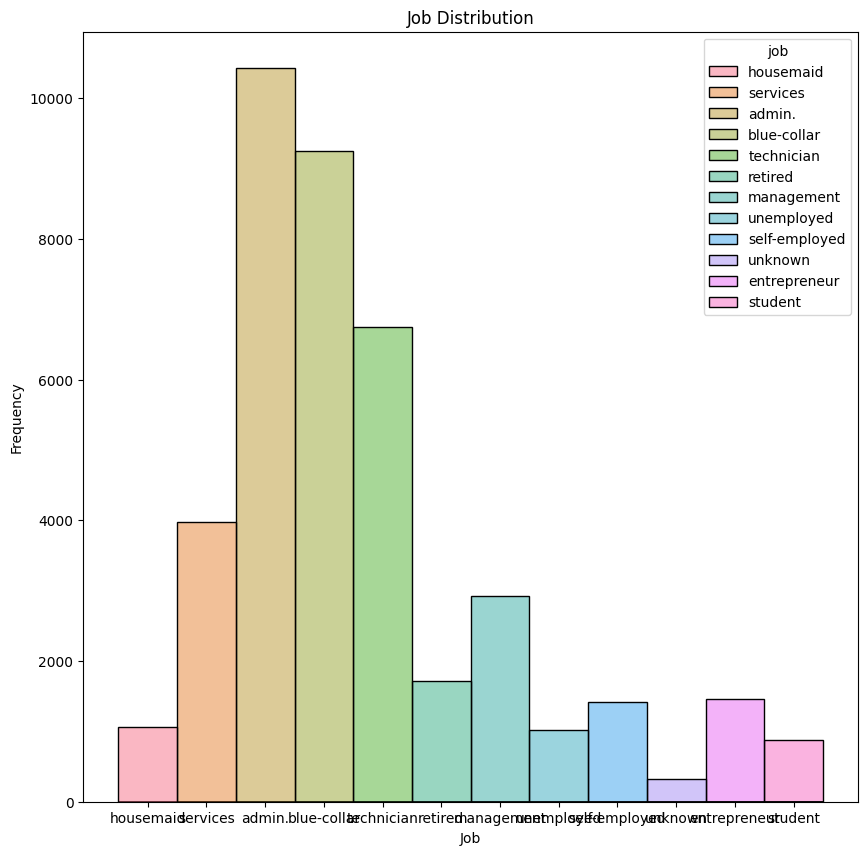

In [12]:
# Job distribution
plt.figure(figsize=(10, 10))
sns.histplot(data=df, x="job", hue="job", kde=True)
plt.title('Job Distribution')
plt.xlabel('Job')
plt.ylabel('Frequency')
plt.show()

## Balance & Deposit Trends

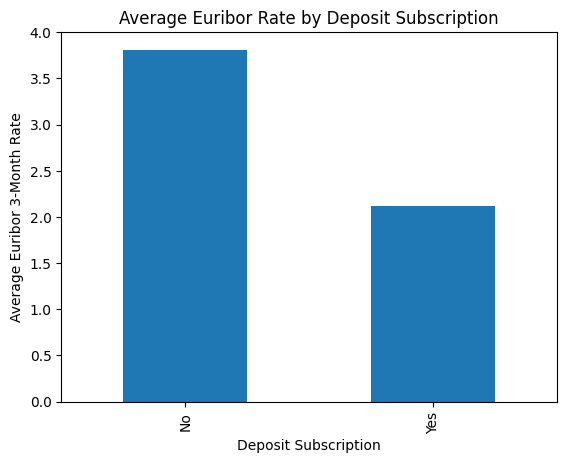

In [13]:
# Average balance by deposit subscription
df.groupby('y')['euribor3m'].mean().plot(kind='bar')
plt.title('Average Euribor Rate by Deposit Subscription')
plt.xlabel('Deposit Subscription')
plt.ylabel('Average Euribor 3-Month Rate')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

## Campaign Effectiveness

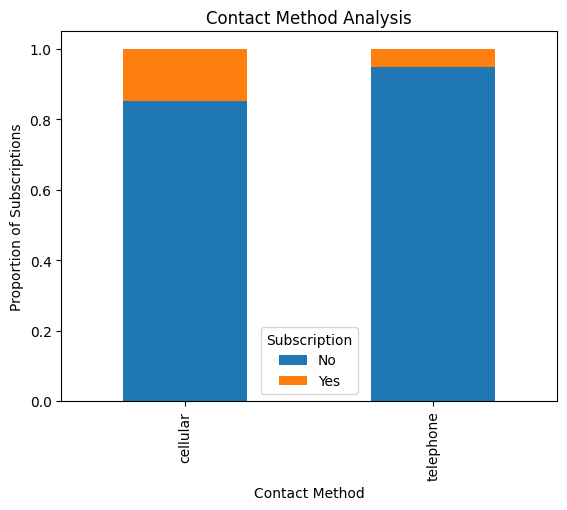

In [14]:
# Contact method analysis
df.groupby('contact')['y'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Contact Method Analysis')
plt.xlabel('Contact Method')
plt.ylabel('Proportion of Subscriptions')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.show()

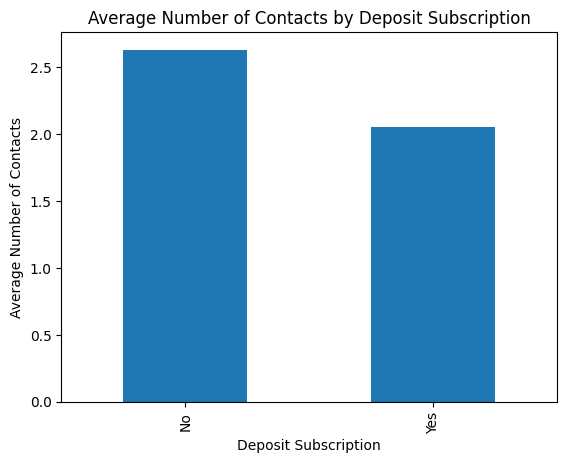

In [15]:
# Number of contacts vs deposit subscription
df.groupby('y')['campaign'].mean().plot(kind='bar')
plt.title('Average Number of Contacts by Deposit Subscription')
plt.xlabel('Deposit Subscription')
plt.ylabel('Average Number of Contacts')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

## Correlation Heatmap

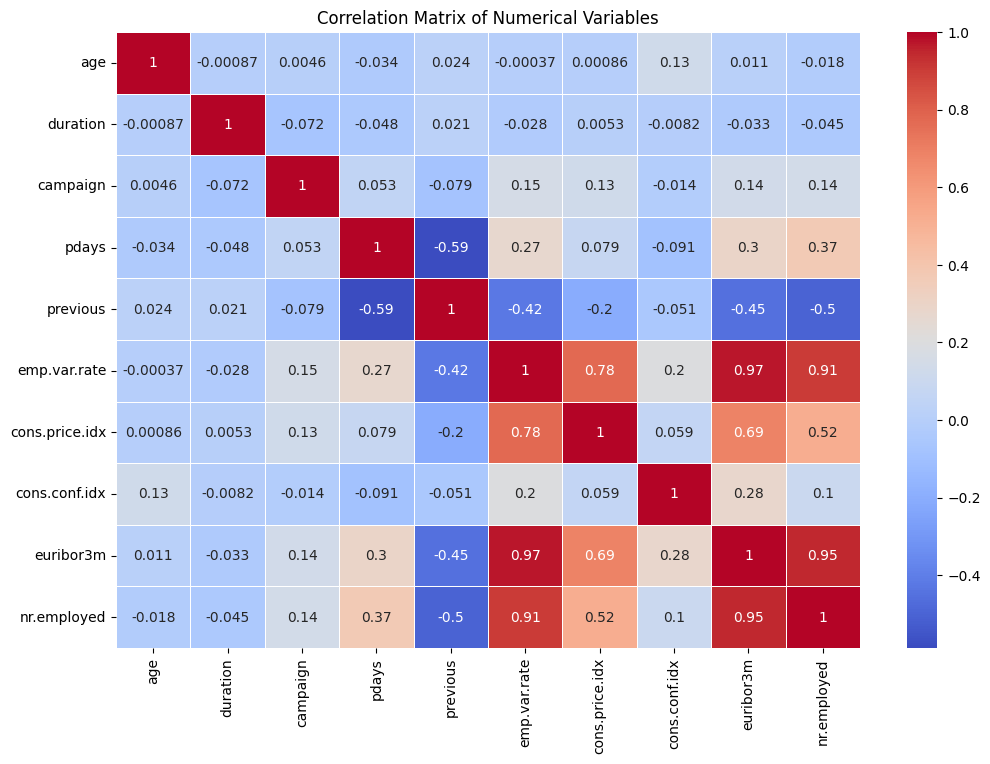

In [16]:
# Correlation of numerical variables
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Predictive Modeling (Logistic Regression)

In [17]:
# Encoding categorical variables using OneHotEncoder
X = df.drop('y', axis=1)
y = df['y']

In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
# Encoding categorical variables
categorical_cols = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            'onehot',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

C:\Users\Dhanush P\AppData\Local\Temp\ipykernel_22464\2701860900.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns


In [20]:
# Fit and transform the training data, and transform the test data
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [21]:
# Scaling the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [22]:
# Model training - Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
# Predictions
predictions = model.predict(X_test_scaled)

In [24]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

Accuracy: 0.9163631949502307
              precision    recall  f1-score   support

          no       0.93      0.98      0.95      7310
         yes       0.71      0.44      0.54       928

    accuracy                           0.92      8238
   macro avg       0.82      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238

[[7145  165]
 [ 524  404]]


In [25]:
# ROC AUC Score
probabilities = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, probabilities)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9424203382235011


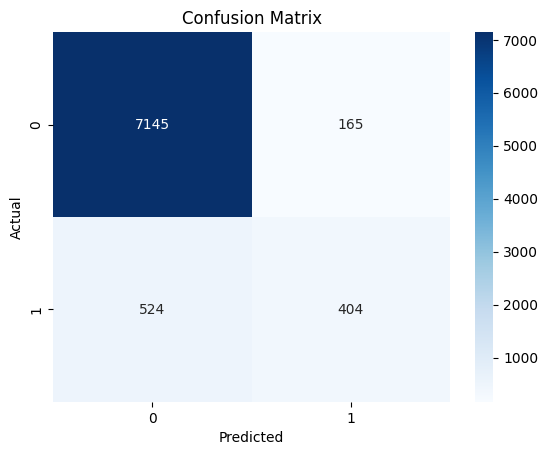

In [26]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.